# AG-HYPOPT · Trial 02

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Trial 01 (the only recorded trial, current best) scored objective 0.0981 +/- 0.0194 with sigma_ref 10.25, lr_mu 10.09, lr_gamma 0.52, gamma_anneal 0.10. Its breakdown showed the error is dominated by mu: mu is underestimated in all eight benchmark experiments (-34% to -47%), rel RMSE 39.8% (bias -22.8 photons), while gamma is comparatively good (rel RMSE 19.5%, one outlier at 3nW Trans05 -41%). The registry therefore holds a single point: there is no objective trend yet, only the fact that the loss is mu-limited. The optimizer is still in the uniform-design phase (1/5 completed), so cell 2 again samples 10 candidates uniformly over the space. Context: frozen pipeline (17f, LAMBDA_MEAN=0, z-form gamma), smoke budget 100x10 on the 8-experiment benchmark.]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_02'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (1/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.1962091006869873, "lr_gamma": 0.43879291473129867, "lr_mu": 25.355643514857007, "sigma_ref": 6.838318842701938}
 2 |      - | {"gamma_anneal": 0.4500753944742405, "lr_gamma": 0.7828484214494358, "lr_mu": 9.697526834165085, "sigma_ref": 6.102932546661364}
 3 |      - | {"gamma_anneal": 0.20622702592952857, "lr_gamma": 0.7259464119004742, "lr_mu": 19.056641569510703, "sigma_ref": 8.001245266106721}
 4 |      - | {"gamma_anneal": 0.3244730931035904, "lr_gamma": 0.7354378388596163, "lr_mu": 15.569616831753196, "sigma_ref": 17.663687985482326}
 5 |      - | {"gamma_anneal": 0.7255769643702574, "lr_gamma": 0.7464518578477002, "lr_mu": 14.790620827000653, "sigma_ref": 8.745051394401962}
 6 |      - | {"gamma_anneal": 0.25947049917879983, "lr_gamma": 0.6088527788556617, "lr_mu": 27.28023523751448, "sigma_ref": 20.511278849453788}
 7 |      - | {"gamma_anneal": 0.23860995046153077, "lr_gamma": 0.9393735172054594

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Trial 01 (current best, objective 0.0981) showed the loss is mu-limited: mu is systematically underestimated everywhere, which points to mu under-convergence rather than a gamma problem. The most direct knob for that is lr_mu, and trial 01 used a low value (10.09) near the bottom of its range, so it is worth probing a much larger mu learning rate. Among the high-lr_mu candidates, candidate 1 (lr_mu 25.36, sigma_ref 6.84, lr_gamma 0.44, gamma_anneal 0.20) raises lr_mu by about 2.5x above trial 01 while keeping gamma_anneal low and lr_gamma moderate, which isolates the mu-LR direction more cleanly than candidate 6 (lr_mu 27.28 but sigma_ref 20.5, a large simultaneous change). Candidate 10 (lr_mu 26.55, sigma_ref 13.76) is a weaker version of the same idea. I choose candidate 1.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.1962091006869873, 'lr_gamma': 0.43879291473129867, 'lr_mu': 25.355643514857007, 'sigma_ref': 6.838318842701938}
Running  1nW Trans05 ... 

μ 9.39 -> 6.47 | γ 8.5 -> 10.06 | NLL 1.24


Running  1nW Trans20 ... 

μ 17.32 -> 14.89 | γ 8.5 -> 8.67 | NLL 2.64


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 96.67 | γ 14.1 -> 13.91 | NLL 3.56


Running 3nW Trans100 ... 

μ 175.71 -> 155.48 | γ 14.1 -> 14.04 | NLL 2.97



Total: 6.6 min


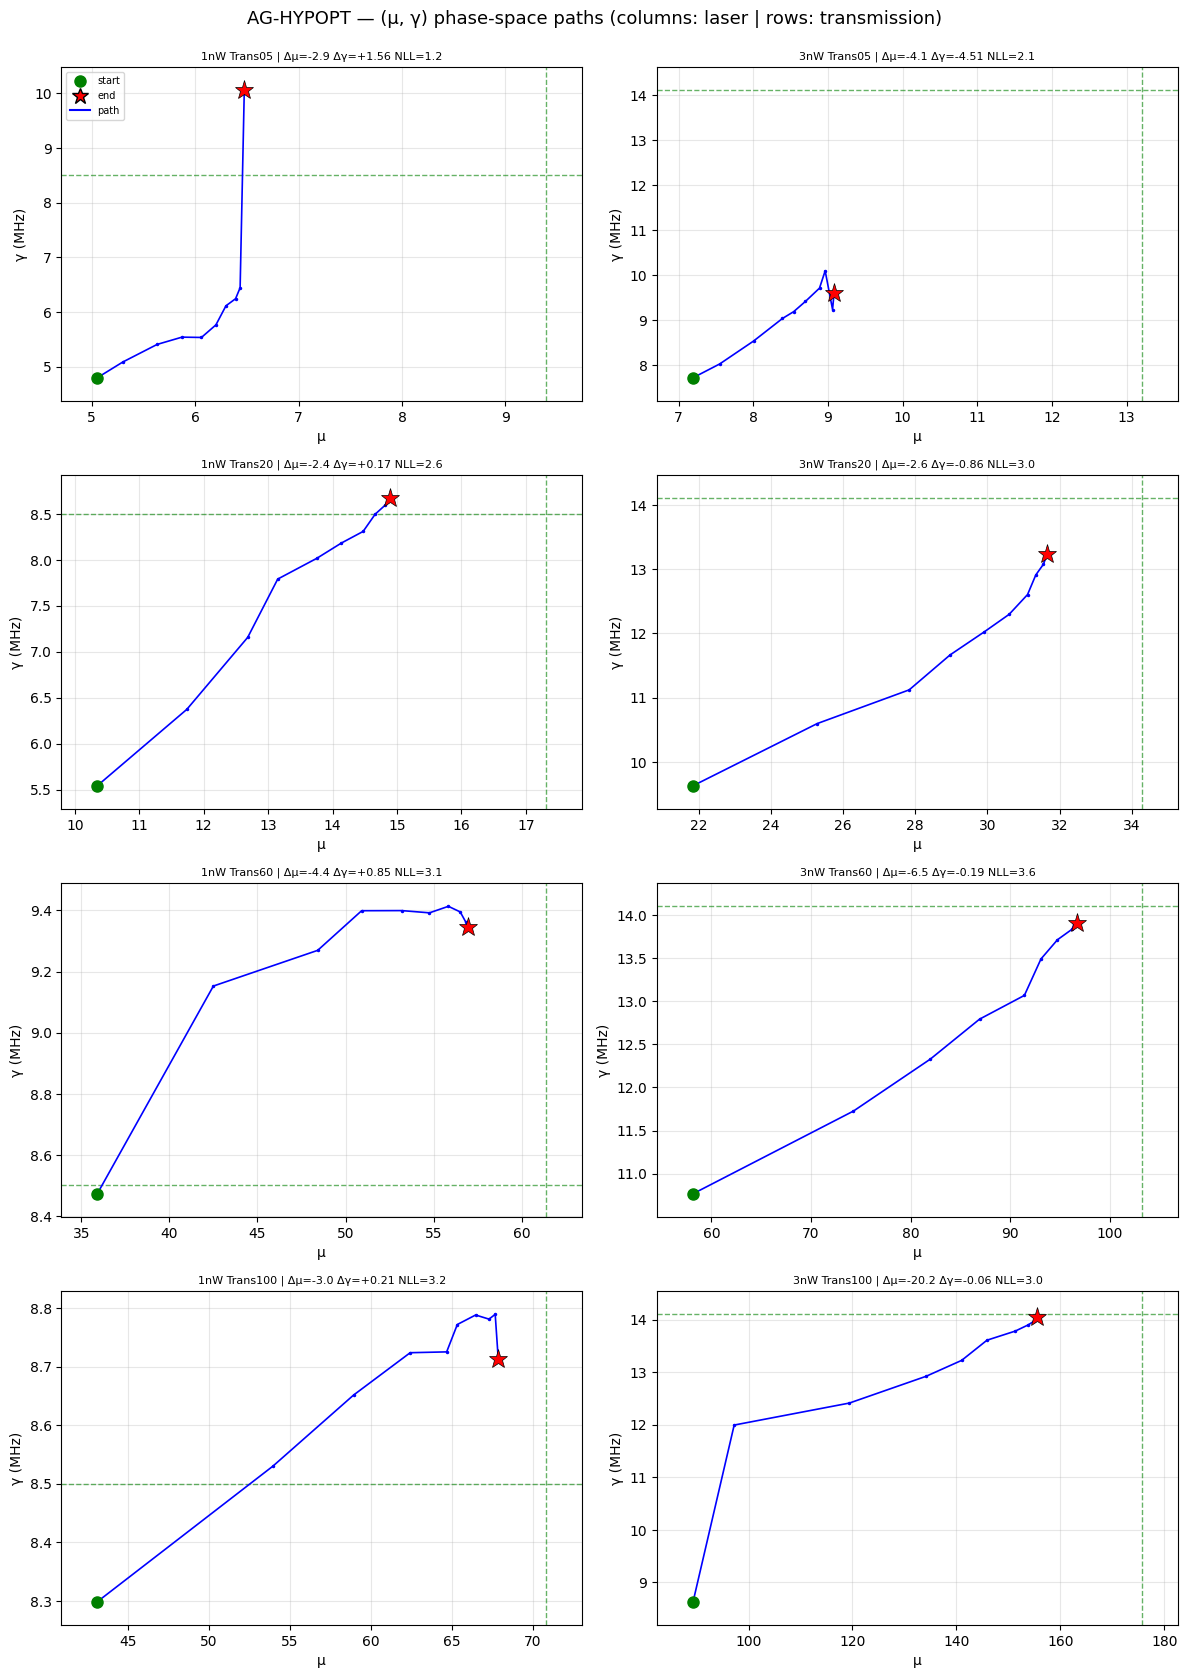

trial finished in 6.6 min
objective = 0.0246 ± 0.0094
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.47   -31.1 |     8.50   10.06   +18.3
1nW Trans20    17.32   14.89   -14.0 |     8.50    8.67    +2.0
1nW Trans60    61.37   56.95    -7.2 |     8.50    9.35   +10.0
1nW Trans100   70.82   67.86    -4.2 |     8.50    8.71    +2.5
3nW Trans05    13.20    9.08   -31.2 |    14.10    9.59   -32.0
3nW Trans20    34.28   31.66    -7.6 |    14.10   13.24    -6.1
3nW Trans60   103.20   96.67    -6.3 |    14.10   13.91    -1.4
3nW Trans100  175.71  155.48   -11.5 |    14.10   14.04    -0.4

μ: RMSE 8.049 (rel 17.5%, bias -5.778) | γ: RMSE 1.743 (rel 13.7%, bias -0.354)


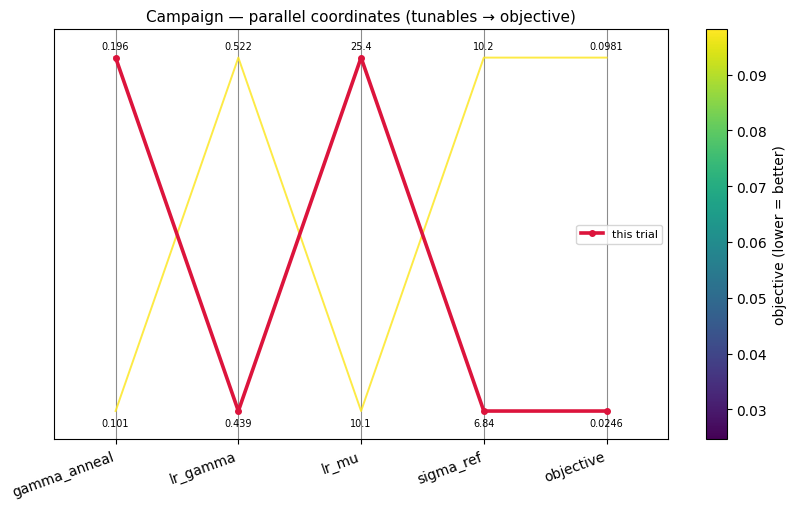

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 02 (sigma_ref 6.84, lr_mu 25.36, lr_gamma 0.44, gamma_anneal 0.20) ran in 6.6 min and scored 0.0246 +/- 0.0094, a ~4x improvement over trial 01 (0.0981) and the new best. The gain is exactly where trial 01 pointed: raising lr_mu by ~2.5x cut the mu error from rel RMSE 39.8% to 17.5% (bias -22.8 -> -5.8 photons). mu is still underestimated everywhere but far less; the high-transmission points that dominated trial 01 are now nearly unbiased (1nW Trans60 -7%, Trans100 -4%, 3nW Trans60 -6%), and the residual mu bias is concentrated at the two Trans05 points (-31% both). gamma improved too, rel RMSE 19.5% -> 13.7%, with the 3nW Trans05 outlier still the worst at -32% (gamma_fit 9.59 vs 14.1). Per-experiment NLL is now 1.24-3.06. So the dominant change between the two trials is lr_mu (accompanied by sigma_ref 10.25 -> 6.84 and lr_gamma 0.52 -> 0.44); mu under-convergence was indeed the main problem, and the remaining error sits in the low-signal regime (Trans05).

**Summary:** Trial 02 (sigma_ref 6.84, lr_mu 25.36, lr_gamma 0.44, gamma_anneal 0.20) scored 0.0246 +/- 0.0094, a ~4x gain over trial 01, driven by a much higher mu learning rate that cut the mu rel RMSE from 39.8% to 17.5%.
**Key insight:** The mu under-shoot was mainly mu under-convergence: raising lr_mu ~2.5x nearly fixed the high-transmission mu bias, leaving the low-signal Trans05 points (-31% mu, -32% gamma at 3nW) as the dominant residual error.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: the residual error is now concentrated at Trans05 (mu_true ~9-13, the lowest photon counts) and the 3nW gamma outlier; later trials should show whether that is signal-limited (nothing hyperparameter-side helps) or still tunable.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 02 (sigma_ref 6.84, lr_mu 25.36, lr_gamma 0.44, gamma_anneal 0.20) scored 0.0246 +/- 0.0094, a ~4x gain over trial 01, driven by a much higher mu learning rate that cut the mu rel RMSE from 39.8% to 17.5%.'
KEY_INSIGHT = 'The mu under-shoot was mainly mu under-convergence: raising lr_mu ~2.5x nearly fixed the high-transmission mu bias, leaving the low-signal Trans05 points (-31% mu, -32% gamma at 3nW) as the dominant residual error.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_02 | current best: trial_02


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_03.ipynb. Open it and follow its cells from the top.
